**1. Loading an Image and Inspecting its Structural Tensor Dimensions**

When you load a color PNG, NumPy represents it as a 3D tensor with dimensions `(Height, Width, Channels)`. The channels represent the RGB (Red, Green, Blue) color intensities, typically scaling from `0` (completely black) to `255` (full intensity) or normalized from `0.0` to `1.0`.

--- Tensor Structural Anatomy ---
Array Data Type (dtype): uint8
Array Shape (H, W, Channels): (400, 400, 3)
Maximum Pixel Value in Array: 255


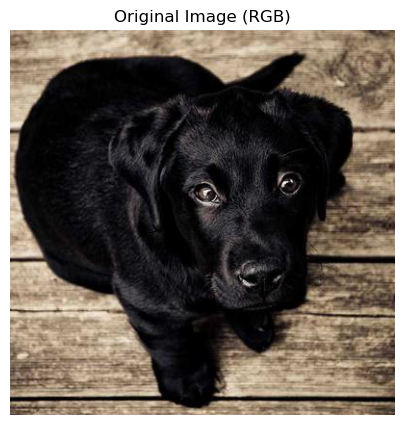

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

# Using a 100% reliable, static developer placeholder image (A dog!)
url = "https://picsum.photos/id/237/400/400"

# We will pass a basic header just to be absolutely safe
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
response.raise_for_status()

# 1. Convert the PIL Image asset directly into a contiguous NumPy array
img_raw = Image.open(BytesIO(response.content))
img_array = np.array(img_raw)

# 2. Inspect the structural blueprint of the image tensor
print("--- Tensor Structural Anatomy ---")
print("Array Data Type (dtype):", img_array.dtype)
print("Array Shape (H, W, Channels):", img_array.shape)
print("Maximum Pixel Value in Array:", np.max(img_array))

# Show the original image in the notebook
plt.figure(figsize=(5, 5))
plt.imshow(img_array)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()

**2. Vectorized Grayscale Transformation (Dimensionality Reduction)**

To convert a color image to black-and-white, we compress the three color channels (RGB) down into a single luminosity channel. Instead of calculating a basic average, we use the standard luminous efficiency weights formula:

$$Y = 0.299R + 0.587G + 0.114B$$

We can implement this using a highly optimized vectorized matrix dot product across the trailing color channel dimension.

New Grayscale Array Shape (Channels compressed): (400, 400)


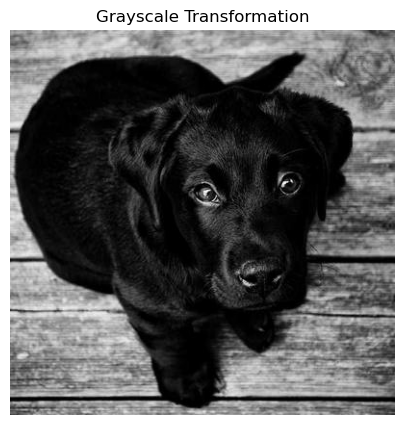

In [3]:
# Extract the first 3 channels (ignoring alpha/transparency if present)
rgb_channels = img_array[:, :, :3]

# Apply luminous intensity multipliers via vector dot product
# Broadcasting a 1D weight array across the 3rd axis of our 3D tensor
weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
grayscale_array = np.dot(rgb_channels, weights).astype(np.uint8)

print("New Grayscale Array Shape (Channels compressed):", grayscale_array.shape)

# Render the grayscale image
plt.figure(figsize=(5, 5))
# cmap="gray" tells matplotlib to map the single intensity dimension to a black-to-white spectrum
plt.imshow(grayscale_array, cmap="gray")
plt.title("Grayscale Transformation")
plt.axis("off")
plt.show()

**3. Spatial Rearrangement (Flipping and Rotating via Slicing)**

Flipping an image is simply reversing the order of values along a specific array axis. Because we are using slicing, NumPy creates an instantaneous operational view without copying any underlying pixel blocks in system memory.

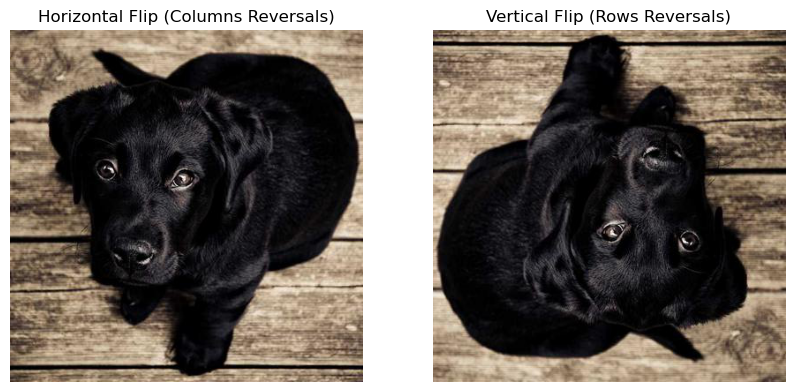

In [4]:
# Syntax review: array[vertical_axis, horizontal_axis]

# 1. Horizontal Flip: Reverse the order of elements along the columns axis (axis 1)
horizontal_flip = img_array[:, ::-1, :]

# 2. Vertical Flip: Reverse the order of elements along the rows axis (axis 0)
vertical_flip = img_array[::-1, :, :]

# Plotting the visual array modifications side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(horizontal_flip)
axes[0].set_title("Horizontal Flip (Columns Reversals)")
axes[0].axis("off")

axes[1].imshow(vertical_flip)
axes[1].set_title("Vertical Flip (Rows Reversals)")
axes[1].axis("off")
plt.show()

**4. Spatial Cropping via Coordinate Slicing**

Cropping means selecting a bounding box sub-grid from your matrix. In object detection pipelines (like YOLO), bounding boxes are extracted by passing explicit bounding pixel index arrays directly to the tensor.

Cropped Fragment Tensor Shape: (200, 200, 3)


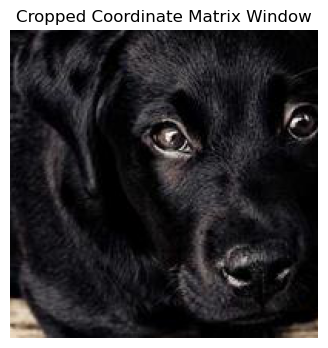

In [5]:
# Let's extract a specific central window of the computer image array
# Define slice boundaries for [height_start:height_end, width_start:width_end]
height_mid, width_mid = img_array.shape[0] // 2, img_array.shape[1] // 2

# Slice out a 200x200 patch centered on the image core
cropped_patch = img_array[height_mid-100:height_mid+100, width_mid-100:width_mid+100, :]

print("Cropped Fragment Tensor Shape:", cropped_patch.shape)

plt.figure(figsize=(4, 4))
plt.imshow(cropped_patch)
plt.title("Cropped Coordinate Matrix Window")
plt.axis("off")
plt.show()

**5. Pixel-Level Mathematical Transformations (Exposure Blinding & Clipping)**

Let's modify individual pixel values directly using scalar math. If we multiply the image array by a scalar value, we increase its exposure brightness.

However, because the array uses the `uint8` data type, any math that pushes a pixel value past $255$ will wrap around back to $0$(overflow error), creating severe visual artifacts. To fix this, we must clip our mathematical limits using `np.clip()`.

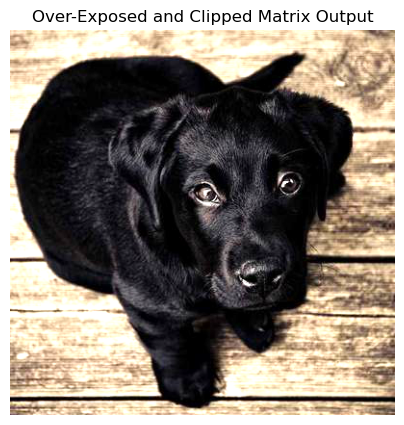

In [6]:
# Intentionally scale pixel intensities up to simulate blinding exposure
# Convert to float to avoid overflow arithmetic errors during the scaling operation
exposed_float = img_array.astype(np.float32) * 1.5

# Clip values to ensure no pixel exceeds the maximum 8-bit limit of 255
exposed_clipped = np.clip(exposed_float, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(exposed_clipped)
plt.title("Over-Exposed and Clipped Matrix Output")
plt.axis("off")
plt.show()

**6. Complete End-to-End Visualisation Dashboard**

To close out your Week 1 project, group all your distinct array operations into a single clean dashboard summary layout using Matplotlib's `plt.subplots` architecture.

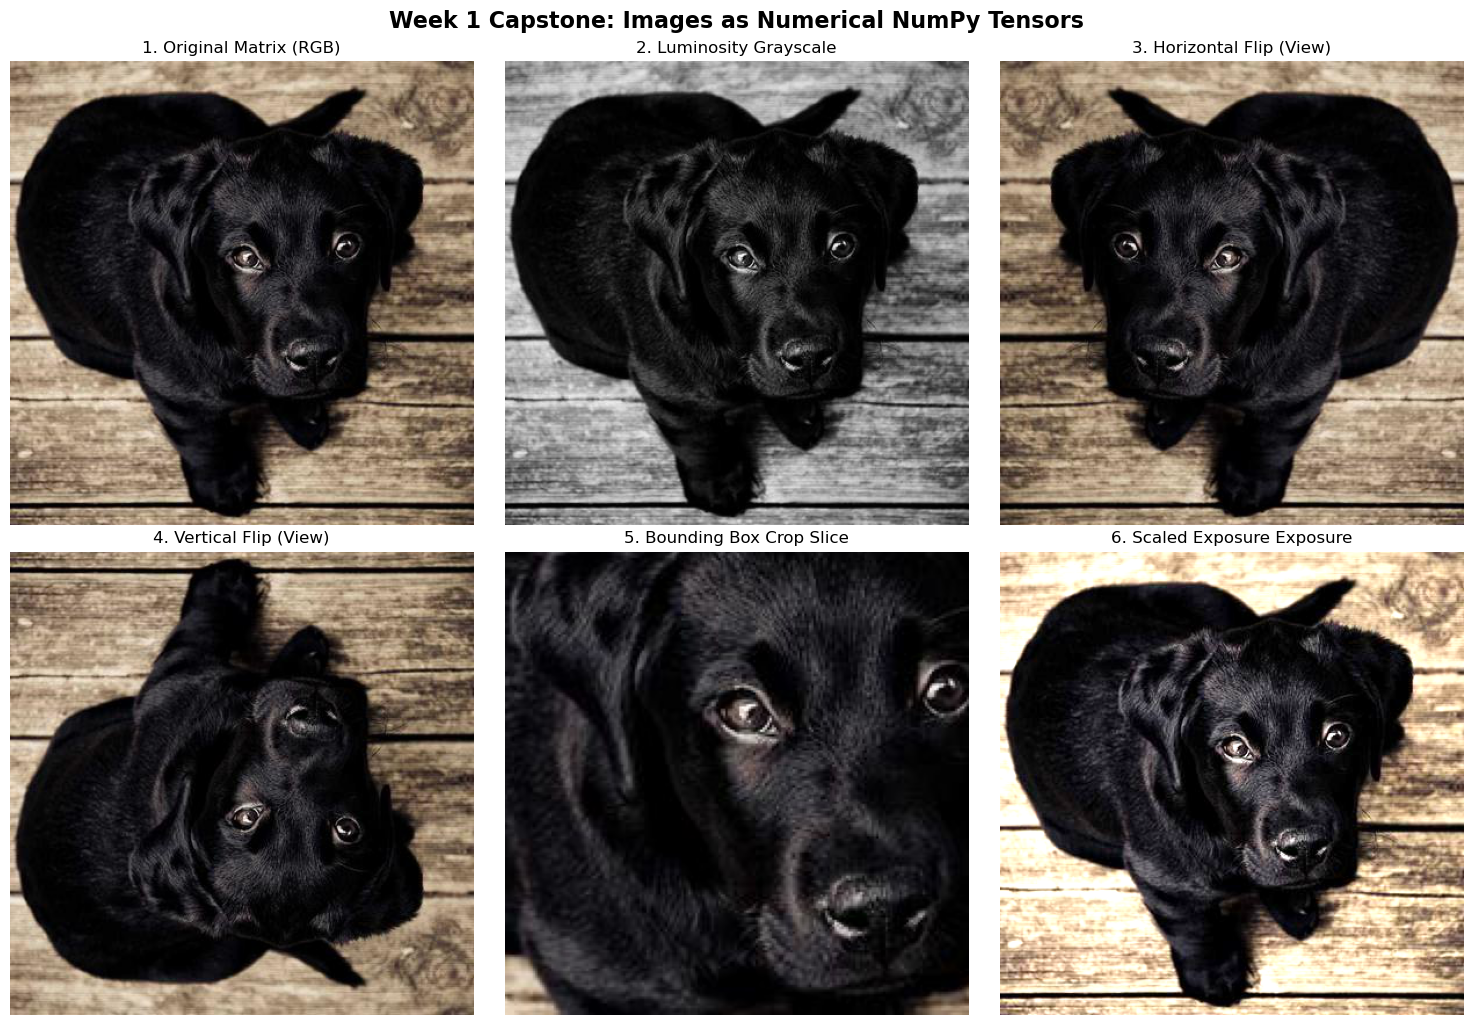

In [10]:
# Instantiate a multi-panel visual grid layout
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes to index them easily in a single loop sequence
axes = axes.flatten()

# Map transformations directly to the subplot display nodes
axes[0].imshow(img_array)
axes[0].set_title("1. Original Matrix (RGB)")

axes[1].imshow(grayscale_array, cmap="gray")
axes[1].set_title("2. Luminosity Grayscale")

axes[2].imshow(horizontal_flip)
axes[2].set_title("3. Horizontal Flip (View)")

axes[3].imshow(vertical_flip)
axes[3].set_title("4. Vertical Flip (View)")

axes[4].imshow(cropped_patch)
axes[4].set_title("5. Bounding Box Crop Slice")

axes[5].imshow(exposed_clipped)
axes[5].set_title("6. Scaled Exposure Exposure")

# Format and clean up the dashboard layout presentation
for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Week 1 Capstone: Images as Numerical NumPy Tensors", y=1.02, fontsize=16, fontweight="bold")
plt.show()